# Prédiction par gradient conjugué matrice-libre (`predictIterative`) vs factorisation de Cholesky

## Contexte

La prédiction en processus gaussien (krigeage) a besoin, à la fois pour
la moyenne **et** l'écart-type, de résoudre un système linéaire de la
forme

$$R\, x = v$$

où $R$ est la matrice de corrélation $n\times n$ du modèle ajusté (à
$\theta^\star$ fixé) et $v$ est un vecteur (un par point de prédiction
pour l'écart-type).

| Approche | Coût | Mémoire | Description |
|----------|------|--------|-------------|
| **Cholesky (`predict`, par défaut)** | $\mathcal{O}(n^3)$ une fois, puis $\mathcal{O}(n^2)$ par résolution en réutilisant le facteur | $\mathcal{O}(n^2)$ (facteur $L$ résident) | Factoriser $R = LL^\top$ une fois, puis résoudre par substitutions triangulaires |
| **Gradient conjugué matrice-libre (`predictIterative`)** | $\mathcal{O}(n^2\cdot\text{itérations})$ par résolution, rien n'est réutilisé d'une résolution à l'autre | $\mathcal{O}(n)$ ($R$ n'est jamais stockée) | Résoudre $Rx=v$ itérativement, en ne calculant que des produits $R\,p$ à la volée |

**L'idée centrale derrière `predictIterative`** : quand le facteur de
Cholesky $L$ n'a jamais été calculé (un modèle ajusté avec un objectif
approché comme `LLVecchia`/`LLNystrom`/`LLIterative`, aucun d'eux ne
maintenant jamais de facteur $n\times n$) — ou simplement quand on ne
veut pas le garder résident juste pour quelques prédictions sur un
ajustement par ailleurs ordinaire — le même résultat *exact* (aux
tolérances numériques près) peut être obtenu sans jamais former ni
factoriser $R$, juste en l'évaluant colonne par colonne via des produits
matrice-vecteur.

Ce notebook parcourt l'algèbre linéaire des deux approches sur un petit
exemple 1D, de sorte que chaque étape (matrice $R$, facteur $L$,
itérations du gradient conjugué) reste visible et interprétable.

**Références de code** : [`PredictIterative.md`](PredictIterative.md),
[`Nystrom.md`](Nystrom.md), [`Scalability.md`](Scalability.md),
[`src/lib/LinearAlgebra.cpp`](../../src/lib/LinearAlgebra.cpp)
(`LinearAlgebra::conjugateGradient`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Exemple : 6 points en 1D

On utilise une fonction test 1D simple, avec très peu de points
d'observation ($n=6$) pour que chaque matrice intermédiaire ($6\times 6$)
reste assez petite pour être affichée et lue directement.

$$f(x) = \sin(6x) + 0.3\cos(18x)$$

On ajuste un modèle de **krigeage ordinaire** : $y(x) = m + Z(x)$ avec
$m$ une constante inconnue et $Z \sim \mathcal{GP}(0,\
\sigma^2\rho(x,x';\theta))$, noyau gaussien
$\rho(x,x';\theta)=\exp(-\|x-x'\|^2/\theta^2)$ (`regmodel='constant'`
dans libKriging).

In [2]:
def f(x):
    return np.sin(6*x) + 0.3*np.cos(18*x)

# 6 points d'observation, volontairement peu nombreux et irrégulièrement espacés
X_o = np.array([[0.05], [0.20], [0.40], [0.55], [0.75], [0.95]])
y_o = f(X_o[:, 0])
n = len(y_o)

X_grid = np.linspace(0, 1, 150).reshape(-1, 1)
y_true = f(X_grid[:, 0])

print(f'n = {n} points d\'observation')
print('X_o =', X_o.ravel())
print('y_o =', np.round(y_o, 4))

n = 6 points d'observation
X_o = [0.05 0.2  0.4  0.55 0.75 0.95]
y_o = [ 0.482   0.663   0.858  -0.4245 -0.7991 -0.604 ]


theta* = 0.1463   sigma2* = 0.4345   beta* = -0.0039


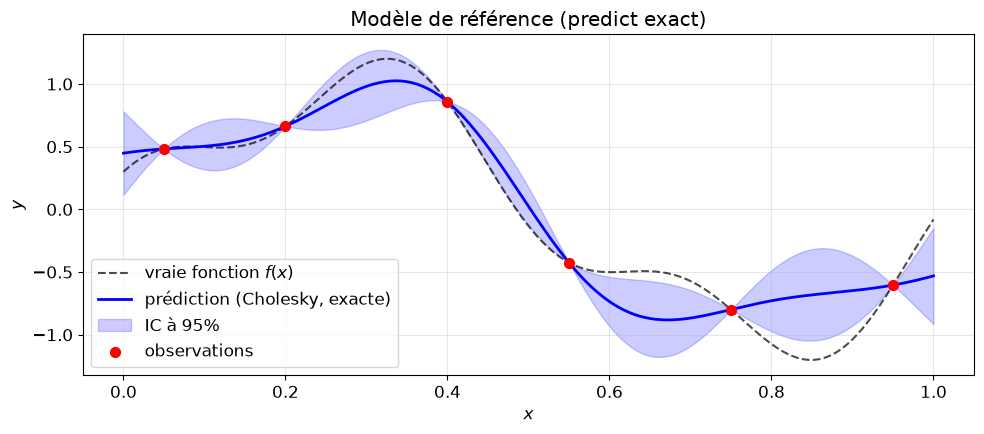

In [3]:
# Ajuster le modèle de krigeage (référence : facteur de Cholesky résident)
model = lk.Kriging(y_o, X_o, 'gauss', regmodel='constant')
mean_exact, stdev_exact = model.predict(X_grid, return_stdev=True)[:2]
mean_exact, stdev_exact = mean_exact.ravel(), stdev_exact.ravel()

theta = model.theta().ravel()[0]
sigma2 = model.sigma2()
beta = model.beta().ravel()
print(f'theta* = {theta:.4f}   sigma2* = {sigma2:.4f}   beta* = {beta[0]:.4f}')

fig, ax = plt.subplots()
ax.plot(X_grid, y_true, 'k--', lw=1.5, alpha=0.7, label='vraie fonction $f(x)$')
ax.plot(X_grid, mean_exact, 'b-', lw=2, label='prédiction (Cholesky, exacte)')
ax.fill_between(X_grid.ravel(), mean_exact - 1.96*stdev_exact, mean_exact + 1.96*stdev_exact,
                 alpha=0.2, color='blue', label='IC à 95%')
ax.scatter(X_o, y_o, c='red', zorder=5, s=50, label='observations')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(loc='lower left'); ax.set_title('Modèle de référence (predict exact)')
plt.tight_layout(); plt.show()

## 2. Rappel : ce que fait `predict()` — Cholesky

Le prédicteur de krigeage ordinaire (moyenne $\hat y$, variance $s^2$) au
point $x$ s'écrit, avec $\mathbb{1}$ le vecteur de $n$ uns, $y$ les
observations, $\sigma^2$ la variance du processus, et $r$ le vecteur de
corrélation entre le point de prédiction $x$ et les $n$ observations :

$$
\hat{y}(x) = \hat{m} + r^\top R^{-1}(y - \hat{m}\,\mathbb{1})
\qquad\qquad
s^2(x) = \sigma^2\left(1 - r^\top R^{-1}r + \frac{\big(1 - \mathbb{1}^\top R^{-1}r\big)^2}{\mathbb{1}^\top R^{-1}\mathbb{1}}\right)
$$

où $\hat m$ (la moyenne constante, estimée par GLS à l'ajustement) est
déjà connue — on ne s'intéresse ici qu'au coût de la *prédiction*, pas
de l'ajustement. Le dernier terme de $s^2(x)$ est l'incertitude
supplémentaire due au fait que $m$ est *estimée* à partir des données
plutôt que connue à l'avance (c'est ce qui distingue le krigeage
ordinaire du krigeage simple, où $m$ est fixée et ce terme s'annule).

Dans les deux formules, la seule opération algébrique coûteuse est un
produit de la forme $R^{-1}v$ : $v = y-\hat m\,\mathbb{1}$ pour la
moyenne (calculé **une seule fois**, partagé entre tous les points de
prédiction), $v = r$ pour la variance (**un $r$ différent par point de
prédiction**). Autrement dit, tout se ramène à résoudre, encore et
encore, un système linéaire de la forme

$$R\, x = v$$

où $R$ est la matrice de corrélation $n\times n$ du modèle ajusté (à
$\theta^\star$ fixé) et $v$ est le second membre requis à ce moment-là
($y-\hat m\,\mathbb{1}$ ou $r$). **C'est exactement ce système que
Cholesky et le gradient conjugué résolvent chacun à sa façon** : Cholesky
en factorisant $R$ une fois et en réutilisant le facteur pour chaque
nouveau $v$ (§2), CG en le résolvant itérativement sans jamais former
$R$ (§3) — deux chemins de calcul différents vers le même
$x=R^{-1}v$, donc vers la même $\hat y(x)$ et $s^2(x)$.

### Factorisation

$R$ étant symétrique définie positive, on factorise $R = LL^\top$ avec
$L$ triangulaire inférieure ($\mathcal{O}(n^3)$, une fois pour tout le
modèle).

**Pourquoi $R=LL^\top$ aide-t-il à résoudre $Rx=v$ ?** Sans
factorisation, résoudre un système $n\times n$ quelconque (élimination
de Gauss) coûte $\mathcal{O}(n^3)$ — et ce coût devrait être payé à
nouveau **pour chaque nouveau $v$** (un $v$ différent par point de
prédiction pour la variance). L'astuce de Cholesky est de remplacer le
système dense $Rx=v$ par deux systèmes *triangulaires* :

$$Rx=v \iff LL^\top x = v \iff \underbrace{Lu = v}_{\text{aller}} \ \text{puis}\ \underbrace{L^\top x = u}_{\text{retour}}$$

Un système triangulaire se résout par simple substitution (chaque
inconnue s'exprime directement à partir des précédentes, aucune
élimination nécessaire) : $\mathcal{O}(n^2)$ au lieu de $\mathcal{O}(n^3)$.
Et surtout, **$L$ ne dépend que de $R$, pas de $v$** : une fois calculée
(le coût $\mathcal{O}(n^3)$, payé une fois à l'ajustement), elle est
réutilisée telle quelle pour tout nouveau second membre $v$ — chaque
prédiction supplémentaire ne coûte plus que les deux substitutions
$\mathcal{O}(n^2)$ ci-dessus, jamais un nouveau $\mathcal{O}(n^3)$. C'est
le chemin par défaut de `predict()` : rapide tant que $L$
($\mathcal{O}(n^2)$ en mémoire) peut rester résidente.

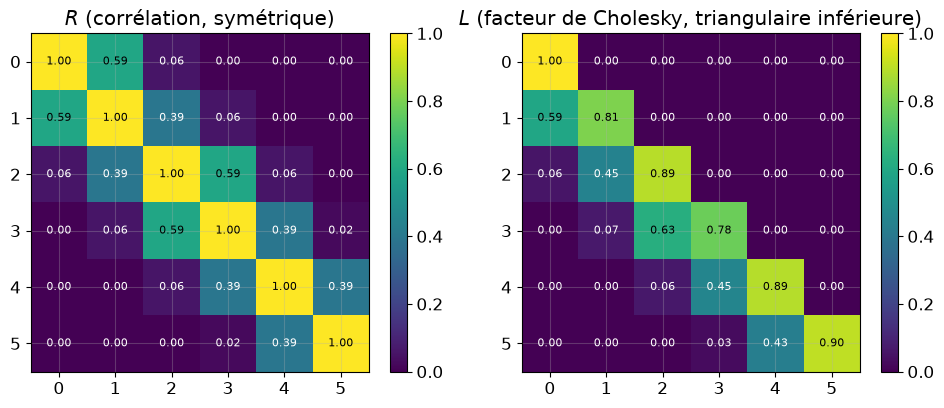

Vérification L L^T = R : True


In [4]:
# Reconstruire R et son facteur de Cholesky L à theta*
R = np.array(model.covMat(X_o, X_o)) / sigma2   # covMat() renvoie sigma2 * R
L = np.linalg.cholesky(R)                       # équivalent au T interne de libKriging

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, M, title in zip(axes, [R, L], ['$R$ (corrélation, symétrique)', '$L$ (facteur de Cholesky, triangulaire inférieure)']):
    im = ax.imshow(M, cmap='viridis', vmin=0)
    ax.set_title(title)
    for i in range(n):
        for j in range(n):
            if M[i, j] != 0 or True:
                ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center',
                         color='white' if M[i, j] < M.max()/2 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print('Vérification L L^T = R :', np.allclose(L @ L.T, R))

In [5]:
# Résolution de Cholesky "à la main" : w = R^{-1}(y - m_hat * 1)
ones_n = np.array(model.F())       # n x 1, vecteur de uns (krigeage ordinaire : F = 1_n)
m_hat = beta                       # moyenne constante déjà estimée par l'ajustement (GLS)
resid = y_o - (ones_n @ m_hat)

u = np.linalg.solve(L, resid)      # résolution aller L u = resid       -- O(n^2)
w_chol = np.linalg.solve(L.T, u)   # résolution retour L^T w = u        -- O(n^2)

# Reconstruire la moyenne prédite sur la grille à partir de ce w
R_on = np.array(model.covMat(X_o, X_grid)) / sigma2   # n x q, corrélations obs<->grille
ones_q = np.ones((X_grid.shape[0], 1))
mean_chol_manual = (ones_q @ m_hat + R_on.T @ w_chol).ravel()

print('max |moyenne manuelle (Cholesky) - predict() exact| =',
      np.abs(mean_chol_manual - mean_exact).max())

max |moyenne manuelle (Cholesky) - predict() exact| = 8.881784197001252e-16


## 3. Le gradient conjugué matrice-libre (CG)

Le gradient conjugué (Hestenes & Stiefel, 1952) résout $Rx=v$ **sans
jamais former ni factoriser $R$** : chaque itération n'a besoin que d'un
produit matrice-vecteur $R p_k$, calculé à la volée. C'est exactement
l'algorithme implémenté par `LinearAlgebra::conjugateGradient` dans
`src/lib/LinearAlgebra.cpp`.

**Initialisation** : $x_0 = 0,\quad r_0 = v - Rx_0 = v,\quad p_0 = r_0$

**Itération $k$** :

$$
\alpha_k = \frac{r_k^\top r_k}{p_k^\top R\, p_k}
\qquad\quad
x_{k+1} = x_k + \alpha_k p_k
\qquad\quad
r_{k+1} = r_k - \alpha_k R p_k
$$
$$
\beta_k = \frac{r_{k+1}^\top r_{k+1}}{r_k^\top r_k}
\qquad\quad
p_{k+1} = r_{k+1} + \beta_k p_k
$$

**Arrêt** : dès que le résidu relatif $\|r_k\|/\|v\|$ passe sous une
tolérance `tol` (par défaut $10^{-8}$), ou après `max_iter` itérations
(par défaut $2n$ dans `predictIterative` : la borne classique de CG en
arithmétique exacte est $n$ itérations, mais les matrices de covariance
de krigeage sont souvent assez mal conditionnées pour que l'erreur vraie
continue de diminuer un peu au-delà de ce point à cause des arrondis).

**Coût par itération** : un seul produit $Rp_k$, soit $\mathcal{O}(n^2)$
opérations et $\mathcal{O}(n)$ de mémoire (seuls des vecteurs sont
stockés, $R$ n'existe jamais explicitement — dans le code C++, `Amul`
est une lambda qui évalue $Rp$ colonne par colonne à la demande). Pour
$k$ itérations, le coût total est $\mathcal{O}(k\,n^2)$ : moins cher que
la factorisation de Cholesky en $\mathcal{O}(n^3)$ dès que $k \ll n$,
mais — contrairement à $L$ — **rien ne se reporte d'une résolution à
l'autre** : chaque nouveau système $Rx=v$ repart de zéro.

In [6]:
def conjugate_gradient(Amul, b, max_iter, tol=1e-12):
    # CG matrice-libre : Amul(p) calcule R@p à la volée, R n'est jamais stockée.
    x = np.zeros_like(b)
    r = b.copy()
    p = r.copy()
    bnorm = np.linalg.norm(b)
    history = {'x': [x.copy()], 'rel_resid': [1.0]}
    rz_old = r @ r
    for k in range(max_iter):
        Ap = Amul(p)
        alpha = rz_old / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rel = np.linalg.norm(r) / bnorm
        history['x'].append(x.copy())
        history['rel_resid'].append(rel)
        if rel < tol:
            break
        rz_new = r @ r
        p = r + (rz_new / rz_old) * p
        rz_old = rz_new
    return x, history

# Résoudre R w = resid par CG matrice-libre (Amul ne voit jamais un R pré-stocké)
w_cg, hist = conjugate_gradient(lambda p: R @ p, resid, max_iter=n, tol=1e-14)

print(f"CG : {len(hist['rel_resid'])-1} itérations pour n={n} (borne théorique : n itérations)")
print('max |w_cg - w_chol| =', np.abs(w_cg - w_chol).max())

CG : 6 itérations pour n=6 (borne théorique : n itérations)
max |w_cg - w_chol| = 8.881784197001252e-16


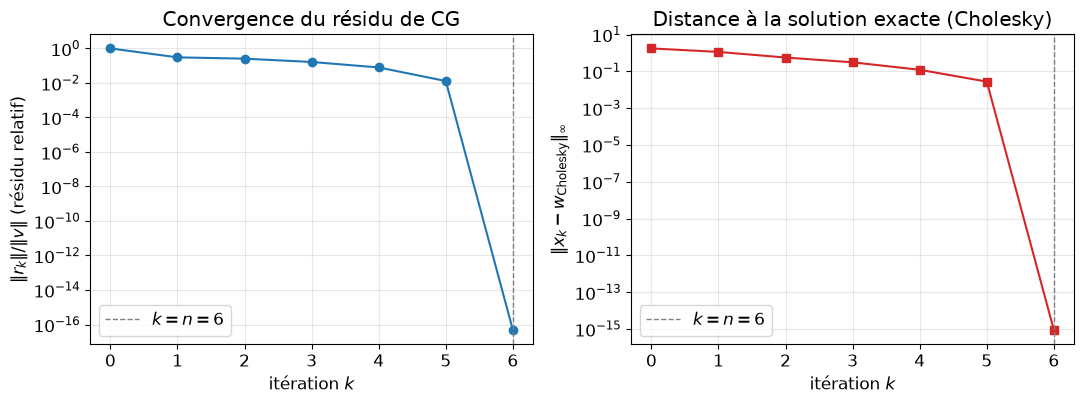

In [7]:
errs_to_exact = [np.abs(x - w_chol).max() for x in hist['x']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogy(range(len(hist['rel_resid'])), hist['rel_resid'], 'o-', color='#1f77b4')
axes[0].set_xlabel('itération $k$'); axes[0].set_ylabel(r'$\|r_k\|/\|v\|$ (résidu relatif)')
axes[0].set_title('Convergence du résidu de CG')
axes[0].axvline(n, color='gray', ls='--', lw=1, label=f'$k=n={n}$')
axes[0].legend()

axes[1].semilogy(range(len(errs_to_exact)), np.maximum(errs_to_exact, 1e-17), 's-', color='#d62728')
axes[1].set_xlabel('itération $k$'); axes[1].set_ylabel(r'$\|x_k - w_{\mathrm{Cholesky}}\|_\infty$')
axes[1].set_title('Distance à la solution exacte (Cholesky)')
axes[1].axvline(n, color='gray', ls='--', lw=1, label=f'$k=n={n}$')
axes[1].legend()
plt.tight_layout(); plt.show()

**Lecture des graphiques** : en arithmétique exacte, CG résout un
système $n\times n$ en **exactement $n$ itérations** (propriété
classique : les directions $p_0,\dots,p_{n-1}$ forment une base
$R$-conjuguée de $\mathbb{R}^n$). On le voit ici — le résidu comme la
distance à la solution de Cholesky s'effondrent tous deux à $k=n=6$. Sur
un vrai modèle à grand $n$, on ne va presque jamais jusqu'à $k=n$ : la
convergence s'arrête bien plus tôt (`tol`), ce qui est précisément ce qui
rend CG intéressant — la convergence pratique est bien plus rapide que la
borne théorique quand le spectre de $R$ est favorable (voir §5).

## 4. Vérification : moyenne et écart-type reconstruits via CG

On reconstruit la prédiction complète (moyenne **et** écart-type) à
partir du seul $w_{\mathrm{CG}}$ obtenu ci-dessus, en réutilisant
exactement les formules du §2, et on compare à `predict()` (Cholesky) et
à `model.predictIterative()` (l'implémentation C++ du même
algorithme).

In [8]:
mean_cg = (ones_q @ m_hat + R_on.T @ w_cg).ravel()

one_Rinv_one = ones_n.T @ np.linalg.solve(R, ones_n)   # scalaire : 1^T R^-1 1
stdev_cg = np.zeros(X_grid.shape[0])
for j in range(X_grid.shape[0]):
    r_on_j = R_on[:, j]
    # Une résolution CG PAR POINT DE PRÉDICTION pour la variance -- le coût dominant, voir §5
    w_j, _ = conjugate_gradient(lambda p: R @ p, r_on_j, max_iter=n, tol=1e-14)
    correction = (1.0 - ones_n.ravel() @ w_j)**2 / one_Rinv_one.item()
    stdev_cg[j] = np.sqrt(max(0.0, sigma2 * (1.0 - r_on_j @ w_j + correction)))

mean_lib_cg, stdev_lib_cg = model.predictIterative(X_grid, return_stdev=True)

print('écart max moyenne : CG à la main vs Cholesky exact          =', np.abs(mean_cg - mean_exact).max())
print('écart max écart-type : CG à la main vs Cholesky exact       =', np.abs(stdev_cg - stdev_exact).max())
print('écart max moyenne : model.predictIterative() vs exact       =', np.abs(mean_lib_cg.ravel() - mean_exact).max())
print('écart max écart-type : model.predictIterative() vs exact    =', np.abs(stdev_lib_cg.ravel() - stdev_exact).max())

écart max moyenne : CG à la main vs Cholesky exact          = 6.661338147750939e-16
écart max écart-type : CG à la main vs Cholesky exact       = 7.114979178740599e-14
écart max moyenne : model.predictIterative() vs exact       = 6.661338147750939e-16
écart max écart-type : model.predictIterative() vs exact    = 1.4230316144198119e-13


**Résultat** : les trois chemins de calcul concordent à la
précision machine près, pour la moyenne comme pour l'écart-type. Le
terme de correction $(1-\mathbb{1}^\top R^{-1}r)^2/(\mathbb{1}^\top
R^{-1}\mathbb{1})$ du §2, calculé ici via une résolution CG partagée
supplémentaire ($R^{-1}\mathbb{1}$, réutilisée pour chaque point de
prédiction tout comme la résolution de la moyenne) au lieu d'une
résolution triangulaire, est ce qui fait la différence : sans lui,
l'écart-type se réduirait à la formule du krigeage *simple* (moyenne
connue) et sous-estimerait l'incertitude dès qu'une tendance est
estimée.

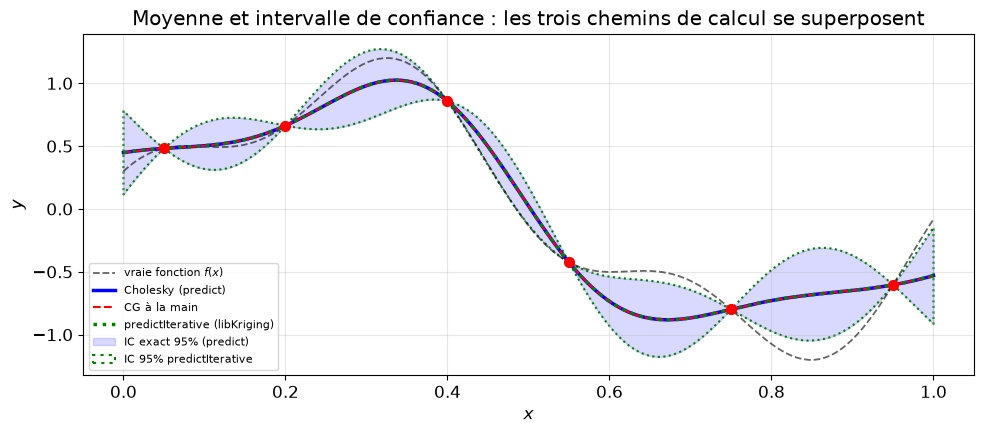

In [9]:
fig, ax = plt.subplots()
ax.plot(X_grid, y_true, 'k--', lw=1.3, alpha=0.6, label='vraie fonction $f(x)$')
ax.plot(X_grid, mean_exact, 'b-', lw=2.5, label='Cholesky (predict)')
ax.plot(X_grid, mean_cg, 'r--', lw=1.5, label='CG à la main')
ax.plot(X_grid, mean_lib_cg.ravel(), 'g:', lw=2.5, label='predictIterative (libKriging)')
ax.fill_between(X_grid.ravel(), mean_exact - 1.96*stdev_exact, mean_exact + 1.96*stdev_exact,
                 alpha=0.15, color='blue', label='IC exact 95% (predict)')
ax.fill_between(X_grid.ravel(), mean_lib_cg.ravel() - 1.96*stdev_lib_cg.ravel(),
                 mean_lib_cg.ravel() + 1.96*stdev_lib_cg.ravel(),
                 facecolor='none', edgecolor='green', linestyle=':', linewidth=1.5, label='IC 95% predictIterative')
ax.scatter(X_o, y_o, c='red', zorder=5, s=50)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(loc='lower left', fontsize=8)
ax.set_title('Moyenne et intervalle de confiance : les trois chemins de calcul se superposent')
plt.tight_layout(); plt.show()

**Point clé sur le coût de l'écart-type** : la boucle à la main du
§4 refait **une résolution CG par point de grille** (150 points), alors
que la moyenne n'en a besoin que d'**une seule, partagée** entre tous
les points. C'est exactement pour cela que
`predictIterative(..., return_stdev=True)` est *optionnel* dans l'API —
son coût est $\mathcal{O}(n^2\cdot\text{itérations}\cdot q)$ pour $q$
points de prédiction, alors que la moyenne seule reste
$\mathcal{O}(n^2\cdot\text{itérations})$, dans la même classe
asymptotique que le coût *total* $\mathcal{O}(n^2)$ de `predict()` exact
(qui amortit sa factorisation sur tous les points).

## 5. Cholesky contre CG en fonction de $n$ : la mémoire d'abord, puis le coût de calcul

Au-delà de l'exemple à $n=6$, deux questions comptent quand $n$
grandit : combien de **mémoire** chaque approche a-t-elle besoin de
garder résidente, et combien d'**opérations** coûte chaque prédiction.
La mémoire est celle qu'on affirme habituellement plutôt qu'on ne montre
-- le §5a la mesure directement. Le §5b couvre ensuite le compromis
(déjà bien connu) en nombre d'opérations, pour être complet.

### 5a. Empreinte mémoire mesurée

`predict()` a besoin d'un facteur de Cholesky $L$ résident ($O(n^2)$) ;
`predictIterative()` a besoin que $R$ ne soit *jamais* formée ($O(n)$) —
*à condition* que le modèle ait été ajusté sans jamais construire $L$ en
premier lieu (un ajustement `LLIterative` léger, voir la mesure mémoire
du côté *ajustement* dans
[lliterative_vs_cholesky.ipynb](lliterative_vs_cholesky.ipynb)). Appeler
`predictIterative()` sur un modèle ajusté *exactement* ne démontre rien
de tel -- $L$ serait déjà résidente du fait de l'ajustement lui-même, CG
ou pas. Chaque point ci-dessous est donc un **sous-processus isolé et
frais** qui ajuste PUIS prédit, puis rapporte sa propre taille résidente
maximale (`resource.getrusage(RUSAGE_SELF).ru_maxrss`) -- ajustement
`LL` exact + `predict()` contre ajustement `LLIterative` léger
(`optim="none"`, $\theta$ fixé, même raisonnement que le notebook
d'ajustement : isole la mémoire du bruit de BFGS) +
`predictIterative()`. Un sous-processus frais par point évite que
l'allocateur mémoire ne conserve de la mémoire d'un point à l'autre au
sein d'un même processus longuement actif.

In [10]:
import subprocess, sys, tempfile, textwrap, os

probe_script = textwrap.dedent('''
    import sys, resource
    import numpy as np
    import pylibkriging as lk

    n = int(sys.argv[1])
    objective = sys.argv[2]

    np.random.seed(0)
    def f(x1, x2):
        return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

    X = np.random.uniform(0, 1, size=(n, 2))
    y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)
    params = {'theta': np.array([[0.3, 0.3]]), 'is_theta_estim': False}

    k = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                   objective=objective, optim='none', parameters=params)
    Xt = np.random.uniform(0, 1, size=(5, X.shape[1]))
    if objective == 'LL':
        k.predict(Xt, True, False, False)
    else:
        k.predictIterative(Xt, True)

    peak_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    print(peak_kb)
''')

probe_path = tempfile.NamedTemporaryFile(suffix='.py', delete=False).name
with open(probe_path, 'w') as fh:
    fh.write(probe_script)


def measure_peak_mb(n, objective):
    out = subprocess.run([sys.executable, probe_path, str(n), objective],
                         capture_output=True, text=True, check=True, timeout=240)
    # La dernière ligne est toujours le peak_kb -- un [WARNING] de non-convergence
    # de CG (attendu à ces tailles pour LLIterative, sans rapport avec la mesure
    # mémoire elle-même) peut apparaître avant sur stdout.
    return int(out.stdout.strip().splitlines()[-1]) / 1024  # Ko -> Mo


n_values_exact = [100, 300, 700, 1500, 3000, 6000, 10000, 15000]
n_values_iter = [50, 200, 500, 1000, 2000, 5000, 10000, 12000]
m_fixed, precond_rank = 15, 20

mem_exact = [measure_peak_mb(n, 'LL') for n in n_values_exact]
for n, m in zip(n_values_exact, mem_exact):
    print(f'exact fit+predict()                        n={n:5d}   RSS max = {m:8.1f} Mo')

mem_iter = [measure_peak_mb(n, f'LLIterative({m_fixed},{precond_rank})') for n in n_values_iter]
for n, m in zip(n_values_iter, mem_iter):
    print(f'LLIterative(15,20) fit+predictIterative()  n={n:5d}   RSS max = {m:8.1f} Mo')

os.unlink(probe_path)

exact fit+predict()                        n=  100   RSS max =    585.0 Mo
exact fit+predict()                        n=  300   RSS max =    585.0 Mo
exact fit+predict()                        n=  700   RSS max =    585.0 Mo
exact fit+predict()                        n= 1500   RSS max =    675.5 Mo
exact fit+predict()                        n= 3000   RSS max =   1047.0 Mo
exact fit+predict()                        n= 6000   RSS max =   3659.2 Mo
exact fit+predict()                        n=10000   RSS max =  11236.3 Mo
exact fit+predict()                        n=15000   RSS max =  24402.3 Mo


LLIterative(15,20) fit+predictIterative()  n=   50   RSS max =    585.0 Mo
LLIterative(15,20) fit+predictIterative()  n=  200   RSS max =    585.0 Mo
LLIterative(15,20) fit+predictIterative()  n=  500   RSS max =    704.5 Mo
LLIterative(15,20) fit+predictIterative()  n= 1000   RSS max =    715.2 Mo
LLIterative(15,20) fit+predictIterative()  n= 2000   RSS max =    585.0 Mo
LLIterative(15,20) fit+predictIterative()  n= 5000   RSS max =    758.1 Mo
LLIterative(15,20) fit+predictIterative()  n=10000   RSS max =    591.3 Mo
LLIterative(15,20) fit+predictIterative()  n=12000   RSS max =    774.6 Mo


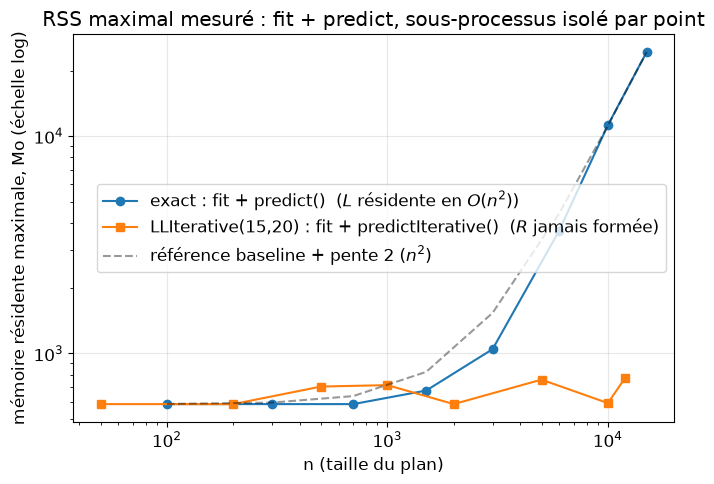

exact : 585 Mo à n=100 -> 24402 Mo à n=15000
LLIterative : 585 Mo à n=50 -> 775 Mo à n=12000  (dominé par le socle fixe Python+numpy+pylibkriging, bouge à peine avec n)


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values_exact, mem_exact, 'o-', label='exact : fit + predict()  ($L$ résidente en $O(n^2)$)')
ax.loglog(n_values_iter, mem_iter, 's-',
          label=f'LLIterative({m_fixed},{precond_rank}) : fit + predictIterative()  ($R$ jamais formée)')

n_arr = np.array(n_values_exact, dtype=float)
baseline = min(mem_exact[0], mem_iter[0])
ax.loglog(n_arr, baseline + (mem_exact[-1] - baseline) * (n_arr / n_arr[-1])**2,
          'k--', alpha=0.4, label=r'référence baseline + pente 2 ($n^2$)')

ax.set_xlabel('n (taille du plan)')
ax.set_ylabel('mémoire résidente maximale, Mo (échelle log)')
ax.set_title('RSS maximal mesuré : fit + predict, sous-processus isolé par point')
ax.legend()
plt.tight_layout()
plt.show()

print(f'exact : {mem_exact[0]:.0f} Mo à n={n_values_exact[0]} -> {mem_exact[-1]:.0f} Mo à n={n_values_exact[-1]}')
print(f'LLIterative : {mem_iter[0]:.0f} Mo à n={n_values_iter[0]} -> {mem_iter[-1]:.0f} Mo à n={n_values_iter[-1]}'
      f'  (dominé par le socle fixe Python+numpy+pylibkriging, bouge à peine avec n)')

### 5b. Coût de calcul théorique (opérations)

La mémoire n'est pas le seul axe -- voici, pour être complet, le
compromis bien connu en nombre d'opérations :

- **Cholesky** : $\mathcal{O}(n^3)$ pour factoriser (une fois), puis $+\
  \mathcal{O}(n^2)$ par résolution (en réutilisant le facteur)
- **CG** : $\mathcal{O}(k\, n^2)$ pour $k$ itérations, **à chaque
  résolution** (rien n'est réutilisé)

`predictIterative` utilise par défaut $k = 2n$ itérations. Le graphique
ci-dessous compare, en nombre d'opérations, la factorisation de Cholesky
à $k$ itérations de CG pour différentes valeurs de $k$.

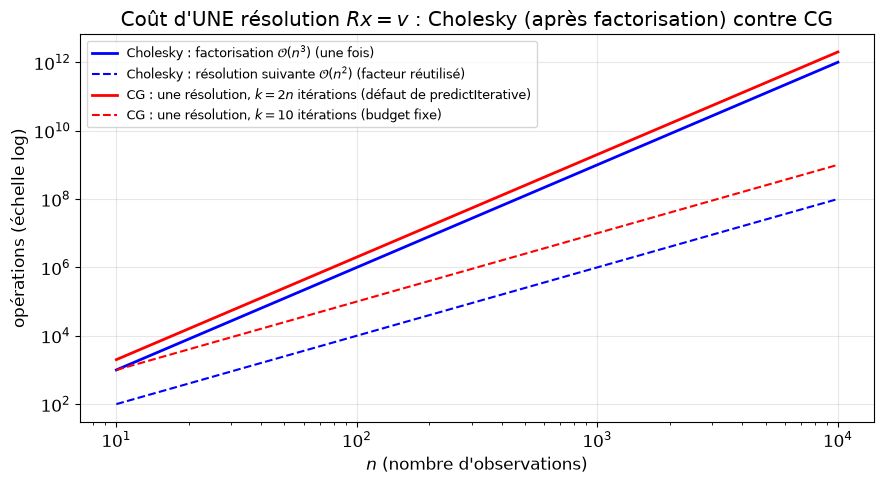

Lecture : si le facteur L existe déjà (un modèle ajusté normalement), une résolution
de Cholesky en O(n^2) reste imbattable. CG devient intéressant quand L N'existe PAS
(un ajustement léger Vecchia/Nystrom/Iterative, ou n trop grand pour garder L résidente) :
la comparaison devient alors n^3 (former L) contre k*n^2 (CG), et CG gagne dès que k << n --
ou simplement dès qu'on ne veut pas payer du tout le coût mémoire O(n^2) de L.


In [12]:
n_range = np.logspace(1, 4, 60)
cost_chol_factor = n_range**3                  # une factorisation
cost_chol_solve  = n_range**2                   # + une résolution (facteur réutilisé)
cost_cg_default  = 2 * n_range * n_range**2      # k = 2n itérations, une résolution
cost_cg_10       = 10 * n_range**2               # budget fixe k=10 itérations

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(n_range, cost_chol_factor, 'b-', lw=2, label=r'Cholesky : factorisation $\mathcal{O}(n^3)$ (une fois)')
ax.loglog(n_range, cost_chol_solve, 'b--', lw=1.5, label=r'Cholesky : résolution suivante $\mathcal{O}(n^2)$ (facteur réutilisé)')
ax.loglog(n_range, cost_cg_default, 'r-', lw=2, label=r'CG : une résolution, $k=2n$ itérations (défaut de predictIterative)')
ax.loglog(n_range, cost_cg_10, 'r--', lw=1.5, label=r'CG : une résolution, $k=10$ itérations (budget fixe)')
ax.set_xlabel('$n$ (nombre d\'observations)'); ax.set_ylabel('opérations (échelle log)')
ax.set_title('Coût d\'UNE résolution $Rx=v$ : Cholesky (après factorisation) contre CG')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print("Lecture : si le facteur L existe déjà (un modèle ajusté normalement), une résolution")
print("de Cholesky en O(n^2) reste imbattable. CG devient intéressant quand L N'existe PAS")
print("(un ajustement léger Vecchia/Nystrom/Iterative, ou n trop grand pour garder L résidente) :")
print("la comparaison devient alors n^3 (former L) contre k*n^2 (CG), et CG gagne dès que k << n --")
print("ou simplement dès qu'on ne veut pas payer du tout le coût mémoire O(n^2) de L.")

## 6. Pour aller plus loin : matrices mal conditionnées et préconditionnement de Nystrom

CG converge plus vite (en pratique, bien avant la borne théorique
$k=n$) quand le spectre de $R$ est plus resserré. Les matrices de
corrélation de krigeage sont cependant souvent mal conditionnées
(noyaux lisses, plans groupés) : plus $\theta$ est grand par rapport à
l'espacement des points, plus $R$ se rapproche d'une matrice de rang 1,
et plus CG a besoin d'itérations pour converger.

`predictIterative` propose un préconditionneur optionnel
(`use_nystrom_precond=True`) : il construit une factorisation de Nystrom
de rang $k_{\text{precond}}$ de $R$ (mêmes landmarks/mécanique que
`LLNystrom`, voir [`Nystrom.md`](Nystrom.md)),

$$R \approx U U^\top, \qquad U = R_{ns}\,L_{ss}^{-\top}\ \ (L_{ss}=\mathrm{chol}(R_{ss}))$$

et l'utilise comme préconditionneur $P^{-1}$ via l'identité de Woodbury
(coût ponctuel $\mathcal{O}(n\cdot k_{\text{precond}}^2)$) — même idée
que le préconditionneur de Cholesky pivoté de GPyTorch. On illustre
ci-dessous l'effet sur un cas volontairement mal conditionné : plus de
points, et un $\theta$ artificiellement grand.

In [13]:
# Un cas plus mal conditionné : plus de points, une grande portée de corrélation (theta imposé)
np.random.seed(1)
n2 = 40
X_o2 = np.sort(np.random.uniform(0, 1, n2)).reshape(-1, 1)
y_o2 = f(X_o2[:, 0])

model_ill = lk.Kriging(y_o2, X_o2, 'gauss', regmodel='constant',
                        parameters={'theta': np.array([[0.8]]), 'estim_theta': False})
R_ill = np.array(model_ill.covMat(X_o2, X_o2)) / model_ill.sigma2()
print(f'nombre de conditionnement de R (theta=0.8, n={n2}) :', np.linalg.cond(R_ill))

X_probe = X_grid[::15]   # une poignée de points de prédiction, pour rester rapide
mean_ref, _ = model_ill.predict(X_probe, return_stdev=False)[:2]
mean_ref = mean_ref.ravel()

iters_range = np.arange(1, 41, 2)
err_plain, err_precond = [], []
# Un budget d'itérations volontairement minuscule (jusqu'à it=1) sur un R aussi
# mal conditionné déclenche, sans surprise, l'avertissement [WARNING] de
# non-convergence de CG à chaque point tant que it est petit -- attendu, c'est
# précisément ce que ce graphique illustre. On coupe juste les descripteurs
# stdout/stderr bas niveau le temps de la boucle pour ne pas polluer la sortie
# de cette cellule avec des dizaines de répétitions du même avertissement.
devnull_fd = os.open(os.devnull, os.O_WRONLY)
saved_fds = (os.dup(1), os.dup(2))
os.dup2(devnull_fd, 1)
os.dup2(devnull_fd, 2)
try:
    for it in iters_range:
        m_p, _ = model_ill.predictIterative(X_probe, return_stdev=False, max_iter=int(it))
        m_c, _ = model_ill.predictIterative(X_probe, return_stdev=False, max_iter=int(it),
                                      use_nystrom_precond=True, precond_rank=15)
        err_plain.append(np.abs(m_p.ravel() - mean_ref).max())
        err_precond.append(np.abs(m_c.ravel() - mean_ref).max())
finally:
    os.dup2(saved_fds[0], 1)
    os.dup2(saved_fds[1], 2)
    os.close(saved_fds[0]); os.close(saved_fds[1]); os.close(devnull_fd)

nombre de conditionnement de R (theta=0.8, n=40) : 1.2727997952497295e+18


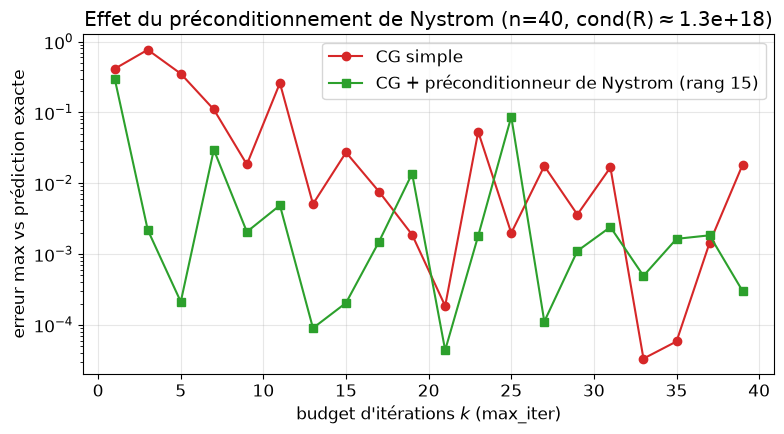

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(iters_range, np.maximum(err_plain, 1e-16), 'o-', color='#d62728', label='CG simple')
ax.semilogy(iters_range, np.maximum(err_precond, 1e-16), 's-', color='#2ca02c', label='CG + préconditionneur de Nystrom (rang 15)')
ax.set_xlabel("budget d'itérations $k$ (max_iter)"); ax.set_ylabel('erreur max vs prédiction exacte')
ax.set_title(f'Effet du préconditionnement de Nystrom (n={n2}, cond(R)$\\approx${np.linalg.cond(R_ill):.1e})')
ax.legend(); plt.tight_layout(); plt.show()

Sur une matrice mal conditionnée, le préconditionneur de Nystrom
atteint une précision donnée avec bien moins d'itérations que CG simple
— au prix d'une mise en place fixe en $\mathcal{O}(n\cdot
k_{\text{precond}}^2)$, payée une fois par appel. C'est optionnel et
indépendant de tout le reste : ni `predictIterative` ni son
préconditionneur ne changent l'objectif ajusté, seulement la façon dont
sont résolus les systèmes linéaires que la prédiction nécessite.

## Conclusion

| | Cholesky (`predict`) | Gradient conjugué (`predictIterative`) |
|---|---|---|
| **Idée** | Factoriser $R=LL^\top$ une fois, réutiliser $L$ | Résoudre $Rx=v$ itérativement, $R$ jamais formée |
| **Coût de la moyenne** | $\mathcal{O}(n^3)$ une fois + $\mathcal{O}(n^2)$ par appel | $\mathcal{O}(n^2\cdot\text{itérations})$, une résolution partagée |
| **Coût de l'écart-type ($q$ points)** | $\mathcal{O}(n^2)$ au total (amorti sur $L$) | $\mathcal{O}(n^2\cdot\text{itérations}\cdot q)$ — une résolution par point |
| **Mémoire** (mesurée, §5a) | $\mathcal{O}(n^2)$ ($L$ résidente) | $\mathcal{O}(n)$ ($R$ jamais matérialisée) |
| **Convergence exacte** | oui, toujours | oui en arithmétique exacte à $k=n$ ; en pratique bien plus tôt si $R$ est bien conditionnée |
| **Quand l'utiliser** | Facteur déjà résident, ou peu de prédictions nécessaires | Facteur jamais calculé (ajustement léger Vecchia/Nystrom/Iterative), ou $n$ trop grand pour garder $L$ résidente juste pour prédire |

Sur cet exemple à 6 points, les trois chemins de calcul (Cholesky à la
main, CG à la main, `model.predictIterative()`) convergent vers
exactement la même moyenne **et** le même écart-type — CG n'est pas une
approximation différente du modèle, c'est **une autre façon de calculer
le même résultat exact**, avec un compromis coût/mémoire différent,
optionnellement accéléré par le préconditionnement de Nystrom quand $R$
est mal conditionnée. Le terme de correction du krigeage ordinaire du
§2 (incertitude sur $\hat m$) s'obtient de la même façon que la moyenne :
une résolution CG partagée supplémentaire au lieu d'une résolution
triangulaire.

### Références

- Hestenes, M. R., & Stiefel, E. (1952). *Methods of conjugate gradients
  for solving linear systems*. Journal of Research of the National
  Bureau of Standards, 49(6), 409-436.
- Williams, C. K. I., & Seeger, M. (2001). *Using the Nystrom method to
  speed up kernel machines*. NeurIPS 13.
- Gardner, J., Pleiss, G., Weinberger, K. Q., Bindel, D., & Wilson,
  A. G. (2018). *GPyTorch: Blackbox matrix-matrix Gaussian process
  inference with GPU acceleration*. NeurIPS 31.
- [`PredictIterative.md`](PredictIterative.md), [`Nystrom.md`](Nystrom.md),
  [`Scalability.md`](Scalability.md)